In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from yellowbrick.classifier import ConfusionMatrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
#LOAD DỮ LIỆU
df = pd.read_csv('/content/Diamonds Prices2022.csv')
df

,Number,Carat,Cut,Color,Clarity,Depth,Table,Price,X,Y,Z
0,1,0.23,Ideal,E,SI2,61.5,55,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...,...
53938,53939,0.86,Premium,H,SI2,61.0,58,2757,6.15,6.12,3.74
53939,53940,0.75,Ideal,D,SI2,62.2,55,2757,5.83,5.87,3.64
53940,53941,0.71,Premium,E,SI1,60.5,55,2756,5.79,5.74,3.49
53941,53942,0.71,Premium,F,SI1,59.8,62,2756,5.74,5.73,3.43


In [ ]:
#THÔNG TIN DỮ LIỆU
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53943 entries, 0 to 53942
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Number   53943 non-null  int64  
 1   Carat    53943 non-null  float64
 2   Cut      53943 non-null  object 
 3   Color    52890 non-null  object 
 4   Clarity  53943 non-null  object 
 5   Depth    53943 non-null  float64
 6   Table    52848 non-null  object 
 7   Price    53943 non-null  int64  
 8   X        53943 non-null  float64
 9   Y        53943 non-null  float64
 10  Z        53943 non-null  float64
dtypes: float64(5), int64(2), object(4)
memory usage: 4.5+ MB


In [ ]:
df.shape


(53943, 11)

In [ ]:
#TÌM TRUNG LẶP
a = df.duplicated().sum()
print('Số dòng dữ liệu bị trùng là:', a)

Số dòng dữ liệu bị trùng là: 0


In [ ]:
#xÓA CỘT NUMBER
df.drop(['Number'], axis=1, inplace=True)
df

,Carat,Cut,Color,Clarity,Depth,Table,Price,X,Y,Z
0,0.23,Ideal,E,SI2,61.5,55,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53938,0.86,Premium,H,SI2,61.0,58,2757,6.15,6.12,3.74
53939,0.75,Ideal,D,SI2,62.2,55,2757,5.83,5.87,3.64
53940,0.71,Premium,E,SI1,60.5,55,2756,5.79,5.74,3.49
53941,0.71,Premium,F,SI1,59.8,62,2756,5.74,5.73,3.43


In [ ]:
#TÌM MISSING VALUES
df.isnull().sum()

Carat         0
Cut           0
Color      1053
Clarity       0
Depth         0
Table      1095
Price         0
X             0
Y             0
Z             0
dtype: int64

In [ ]:
df.dtypes


Carat      float64
Cut         object
Color       object
Clarity     object
Depth      float64
Table       object
Price        int64
X          float64
Y          float64
Z          float64
dtype: object

In [ ]:
#CHUYỂN CỘT VỀ TABLE VỀ KIỂU DỮ LIỆU SỐ
df['Table'] = pd.to_numeric(df['Table'], errors='coerce')
df
#LOẠI BỎ MISSING VALUE Ở CỘT COLOR
df.dropna(subset = ['Color'], inplace=True)
df

,Carat,Cut,Color,Clarity,Depth,Table,Price,X,Y,Z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74
53939,0.75,Ideal,D,SI2,62.2,55.0,2757,5.83,5.87,3.64
53940,0.71,Premium,E,SI1,60.5,55.0,2756,5.79,5.74,3.49
53941,0.71,Premium,F,SI1,59.8,62.0,2756,5.74,5.73,3.43


In [ ]:
#THAY THẾ MISSING VALUE Ở CỘT TABLE BẰNG MEDIAN
df['Table']=df['Table'].fillna(np.floor(df['Table'].median()))
df


,Carat,Cut,Color,Clarity,Depth,Table,Price,X,Y,Z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74
53939,0.75,Ideal,D,SI2,62.2,55.0,2757,5.83,5.87,3.64
53940,0.71,Premium,E,SI1,60.5,55.0,2756,5.79,5.74,3.49
53941,0.71,Premium,F,SI1,59.8,62.0,2756,5.74,5.73,3.43


In [ ]:
df.describe()

,Carat,Depth,Table,Price,X,Y,Z
count,52890.000000,52890.000000,52890.000000,52890.000000,52890.000000,52890.000000,52890.000000
mean,0.797906,61.750055,57.439310,3933.667045,5.731213,5.734675,3.538790
std,0.473596,1.430103,2.191326,3990.120085,1.121475,1.142411,0.705764
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5325.750000,6.540000,6.540000,4.040000
max,4.500000,79.000000,95.000000,18823.000000,10.230000,58.900000,31.800000


In [ ]:
#XÓA THÊM CỘT
df = df.drop('X', axis = 1)
df = df.drop('Y', axis = 1)
df = df.drop('Z', axis = 1)

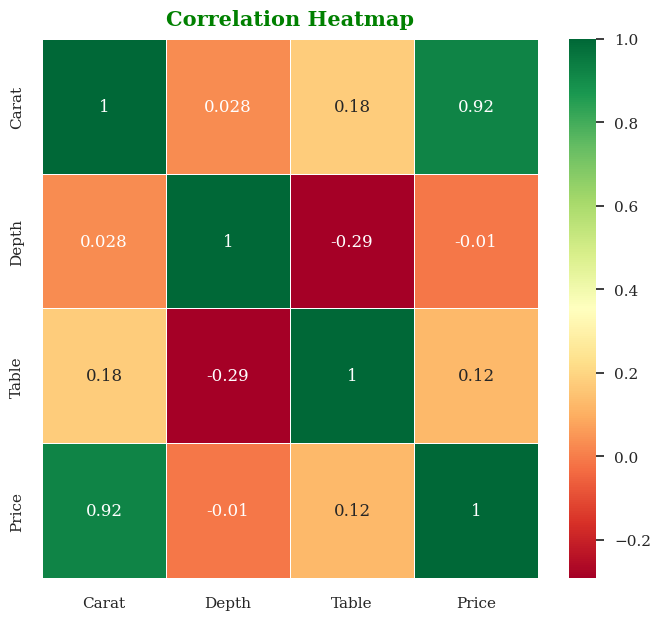

In [ ]:
#VẼ HEATMAP
df_num = df.select_dtypes(include=['number'])
df_num
corr_matrix = df_num.corr()
corr_matrix
sns.set_theme(font='serif')
plt.figure(figsize=(8,7))
sns.heatmap(corr_matrix,annot=True,cmap='RdYlGn',linewidths=0.5)
plt.title('Correlation Heatmap', fontdict={'fontweight': 'bold'}, fontsize=15, color='green',pad=10)
plt.show()

In [ ]:
#PHÂN CHIA BIẾN MỤC TIÊU VÀ CÁC BIẾN ĐẶC TRƯNG
X = df.drop('Price', axis = 1)
X = X.values
y = df['Price']

In [ ]:
#MÃ HÓA CÁC CỘT CUT,COLR,CLARITY SANG DẠNG SỐ
from sklearn.preprocessing import LabelEncoder
label_encoder_cut = LabelEncoder()
label_encoder_color = LabelEncoder()
label_encoder_clarity = LabelEncoder()
X[:,1] = label_encoder_cut.fit_transform(X[:,1])
X[:,2] = label_encoder_color.fit_transform(X[:,2])
X[:,3] = label_encoder_clarity.fit_transform(X[:,3])

In [ ]:
#SCALE DỮ LIỆU
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_standard = scaler.fit_transform(X)
y_standard = scaler.fit_transform(y.values.reshape(-1,1))

In [ ]:
#CHIA TẬP DỮ LIỆU THÀNH TẬP HUẤN LUYỆN VÀ KIỂM TRA
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

In [ ]:
X_train.shape, y_train.shape

((37023, 6), (37023,))

In [ ]:
X_test.shape, y_test.shape

((15867, 6), (15867,))

In [ ]:
#Linear Regression
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()

In [ ]:
lr_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
lr_normal_score_train = lr_model.score(X_train, y_train)
lr_normal_score_train

0.8785519355655259

In [ ]:
lr_normal_score_test = lr_model.score(X_test, y_test)
lr_normal_score_test


0.879252184608822

In [ ]:
# Hệ số hồi qui và hệ số chặn
print(lr_model.coef_)
print(lr_model.intercept_)

[8298.17650354   74.08158805 -225.37480013  303.74354435 -104.75925862
  -94.5076182 ]
8639.563395829911


In [ ]:
previsoes = lr_model.predict(X_test)
previsoes

array([6439.91963985, 3074.25254183, 3421.35501426, ..., 1004.49211959,
       3448.7971718 , 4676.81036112])

In [ ]:
#MSE
mse_lr_normal = mean_absolute_error(y_test, previsoes)
mse_lr_normal


926.2507237524522

In [ ]:
#RMSE
rmse_lr_normal = np.sqrt(mean_squared_error(y_test, previsoes))
rmse_lr_normal

1384.2926579347118

In [ ]:
#Linear Regression (Ridge)
from sklearn.linear_model import Ridge
modelRidge = Ridge(alpha=10)
modelRidge.fit(X_train, y_train)

Ridge(alpha=10)

In [ ]:
# Sai số huấn luyện của mô hình trên tập train
lr_ridge_score_train = modelRidge.score(X_train, y_train)
lr_ridge_score_train

0.8785502976397341

In [ ]:
# Sai số huấn luyện của mô hình trên tập test
lr_ridge_score_test = modelRidge.score(X_test, y_test)
lr_ridge_score_test

0.8792380868967566

In [ ]:
pre = modelRidge.predict(X_test)
pre

array([6438.55944629, 3075.22202657, 3421.06686511, ..., 1007.90757006,
       3448.88166027, 4677.29388992])

In [ ]:
#MSE
mse_modelRidge = mean_absolute_error(y_test, pre)
mse_modelRidge


925.6071616630047

In [ ]:
#RMSE
rmse_modelRidge = np.sqrt(mean_squared_error(y_test, pre))
rmse_modelRidge

1384.3734659793745

In [ ]:
# Hệ số hồi qui và hệ số chặn
print(modelRidge.coef_)
print(modelRidge.intercept_)


[8286.56285943   74.1074149  -224.5617915   303.11342224 -104.51013374
  -94.08129556]
8608.491293989155


In [ ]:
#Linear Regression (Lasso)
from sklearn.linear_model import Lasso
modelLasso = Lasso(alpha=10, max_iter = 5000, tol = 0.1)
modelLasso.fit(X_train, y_train)

Lasso(alpha=10, max_iter=5000, tol=0.1)

In [ ]:
# Sai số huấn luyện của mô hình trên tập train
lr_lasso_score_train = modelLasso.score(X_train, y_train)
lr_lasso_score_train

0.8783304113337437

In [ ]:
# Sai số huấn luyện của mô hình trên tập test
lr_lasso_score_test = modelLasso.score(X_test, y_test)
lr_lasso_score_test

0.8788811984929743

In [ ]:
prev = modelLasso.predict(X_test)
prev

array([6452.05407147, 3103.34207657, 3414.23271911, ..., 1020.21942465,
       3425.19548732, 4647.20093388])

In [ ]:
#MSE
mse_modelLasso = mean_absolute_error(y_test, prev)
mse_modelLasso


919.4717409886467

In [ ]:
#RMSE
rmse_modelLasso = np.sqrt(mean_squared_error(y_test, prev))
rmse_modelLasso

1386.4175804379372

In [ ]:
# Hệ số hồi qui và hệ số chặn
print(modelLasso.coef_)
print(modelLasso.intercept_)


[8174.36134552   71.06314397 -216.6727439   299.04048357  -85.79211332
  -84.45236936]
6985.059549956206


In [ ]:
linear_regression = {'Model':'Linear Regression',
               'Score Train':lr_normal_score_train,
               'Score Test':lr_normal_score_test,
               'MSE':mse_lr_normal,
               'RMSE':rmse_lr_normal,}

linear_regression_ridge = {'Model':'Linear Regression - Ridge',
               'Score Train':lr_ridge_score_train,
               'Score Test':lr_ridge_score_test,
               'MSE':mse_modelRidge,
               'RMSE':rmse_modelRidge,}

linear_regression_lasso = {'Model':'Linear Regression - Lasso',
               'Score Train':lr_lasso_score_train,
               'Score Test':lr_lasso_score_test,
               'MSE':mse_modelLasso,
               'RMSE':rmse_modelLasso,}
resume = pd.DataFrame({'Linear Regression':pd.Series(linear_regression),
                       'Linear Regression - Ridge':pd.Series(linear_regression_ridge),
                       'Linear Regression - Lasso':pd.Series(linear_regression_lasso)})
resume

,Linear Regression,Linear Regression - Ridge,Linear Regression - Lasso
Model,Linear Regression,Linear Regression - Ridge,Linear Regression - Lasso
Score Train,0.878552,0.87855,0.87833
Score Test,0.879252,0.879238,0.878881
MSE,926.250724,925.607162,919.471741
RMSE,1384.292658,1384.373466,1386.41758
